### Gym Gridworld - RL

In [1]:
import gymnasium
from gymnasium.wrappers import FlattenObservation, HumanRendering, RecordEpisodeStatistics, RecordVideo
import numpy as np
from tqdm import tqdm 

from src.environments.gridworld import GridWorldEnv, DiscreteGridWorldWrapper, Cells, Actions

from src.agents.QLambdaAgent import QLambdaAgent
from src.agents.DQNAgent import DQNAgent

from src.solvers.GridWorldSolver import GridWorldSolver
from src.utility.SessionRunner import play_game

### Learning how to set up the environment

Cound create environment directly like this:  
```py
env = GridWorldEnv()
``` 
However, the environment is registered in gymnasium in the __init__.py files in *environments*, so it can also be created via *gymnasium.make*

In [ ]:
# Custom grid world layout
huge_grid = np.array((
    [0,0,0,0,0,0,3,3,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,0,0,3,0,0,0,0],
    [0,0,0,0,0,0,3,0,3,3,3,3,3,0,0,0,0,3,0,0,0,0,0,0,0,3,0,0,0,3,0,0],
    [0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,3,0,3,0,3,0,0],
    [0,0,0,0,0,0,3,0,0,0,0,0,3,0,0,3,3,3,0,0,0,0,0,0,0,3,3,3,3,3,0,0],
    [0,0,0,0,0,0,3,3,3,3,3,0,3,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,3,3,3,3,3,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,3,3,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,0,3,0,0,3,0,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,0,3,3,3,3,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,3,3,3,3,3,3,3,3,0,0,3,3,3,3,3,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,3,3,3,3,3,0,0,0,3,3,3,3,0,0],
    [3,3,3,3,0,3,3,3,3,3,3,3,3,3,0,3,0,0,3,3,3,3,3,0,0,0,3,0,0,0,0,0],
    [3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,2,2,3,3,3,3,3,0,0,0,3,0,0,0,0,0],
    [3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,0,3,3,3,3,3,0,0,0,3,0,0,1,0,0],
    [3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,3,3,3,3,3,0,0,0,3,0,0,0,0,0],
    [3,3,0,3,3,0,3,3,3,0,3,3,3,3,3,3,0,0,0,0,0,0,0,0,0,0,3,3,3,3,3,0],
    [0,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,2,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0]
))

# Custom reward structure
huge_world_reward: dict = {
    Cells.TILE.value: -0.5, # step on regular cell
    Cells.TARGET.value: 1000.0, # good ending
    Cells.PITFALL.value: -100.0, # bad ending
    Cells.WALL.value: -2.0 # hit obstacle
} # Adjusting the rewards can be considered hyperparameter tuning - we can help the mode converge faster by representing the reward structure better

# Environment
env = gymnasium.make(id="gymnasium_env/GridWorld-v0", grid=huge_grid, reward=huge_world_reward, render_mode=None)
# or env = GridWorldEnv(grid=huge_grid, reward=huge_world_reward, render_mode=None)

In [3]:
env.observation_space

Dict('agent': Box(0, [19 32], (2,), int64))

In [5]:
obs, info = env.reset()
print("Observation: ", obs)
print("Info: ", info)

Observation:  {'agent': array([11,  4])}
Info:  {'distance': np.float64(28.0)}


In [7]:
# Wrappers can be used on the env for various purposes, like flattening observations into a single array
wrapped_env = FlattenObservation(env)
wrapped_env.observation_space

Box(0, [19 32], (2,), int64)

This is particularly useful when working with algorithms that expect specific input formats (like neural networks that need 1D arrays instead of dictionaries).

In [ ]:
obs, info = wrapped_env.reset()
print("Observation: ", obs)

Observation:  [ 4 15]


: 

### Training Agent - Q Lambda

In [2]:
# Custom grid world layout
huge_grid = np.array((
    [0,0,0,0,0,0,3,3,3,3,3,3,3,3,3,3,3,3,0,0,0,0,0,0,0,0,0,3,0,0,0,0],
    [0,0,0,0,0,0,3,0,3,3,3,3,3,0,0,0,0,3,0,0,0,0,0,0,0,3,0,0,0,3,0,0],
    [0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,3,0,3,0,3,0,0],
    [0,0,0,0,0,0,3,0,0,0,0,0,3,0,0,3,3,3,0,0,0,0,0,0,0,3,3,3,3,3,0,0],
    [0,0,0,0,0,0,3,3,3,3,3,0,3,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,3,3,3,3,3,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,3,3,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,0,3,0,0,3,0,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,0,3,3,3,3,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,3,3,3,3,3,3,3,3,3,0,0,3,3,3,3,3,0,0,0,0,0,0,3,0,0],
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,3,3,3,3,3,0,0,0,3,3,3,3,0,0],
    [3,3,3,3,0,3,3,3,3,3,3,3,3,3,0,3,0,0,3,3,3,3,3,0,0,0,3,0,0,0,0,0],
    [3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,2,2,3,3,3,3,3,0,0,0,3,0,0,0,0,0],
    [3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,0,0,3,3,3,3,3,0,0,0,3,0,0,1,0,0],
    [3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,3,3,3,3,3,0,0,0,3,0,0,0,0,0],
    [3,3,0,3,3,0,3,3,3,0,3,3,3,3,3,3,0,0,0,0,0,0,0,0,0,0,3,3,3,3,3,0],
    [0,0,0,0,0,0,0,3,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,2,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0]
))

# Custom reward structure
huge_world_reward: dict = {
    Cells.TILE.value: -0.5, # step on regular cell
    Cells.TARGET.value: 1000.0, # good ending
    Cells.PITFALL.value: -100.0, # bad ending
    Cells.WALL.value: -2.0 # hit obstacle
} # Adjusting the rewards can be considered hyperparameter tuning - we can help the mode converge faster by representing the reward structure better

In [7]:
env = GridWorldEnv(grid=huge_grid, reward=huge_world_reward, wind_p=0.2, render_mode="rgb_array")
# Create a wrapper that maps gridworld position to state integer
wrapped_env = DiscreteGridWorldWrapper(env)

In [8]:
q_lambda_learner_kwargs = {
    "gamma": 0.95, # discount factor for Q' when computing delta ( delta = r + gamma * Q' - Q(s, a) )
    "alpha": 0.01, # 'learning rate' - affects step size in direction of delta when updating Q
    "epsilon": 1.0, # exploration threshold
    "xi": 0.99, # exploration threshold decay
    "lam": 0.6 # λ parameter ; Reflects how far back credit assignment goes
}

In [9]:
solver = GridWorldSolver(wrapped_env, QLambdaAgent, q_lambda_learner_kwargs, verbose=True)

In [10]:
n_epochs, reward_history, total_reward_history = solver.train(n_epochs=5000)

Epoch: 100%|██████████| 5000/5000 [01:06<00:00, 75.07it/s] 

Total reward = 2657499.0


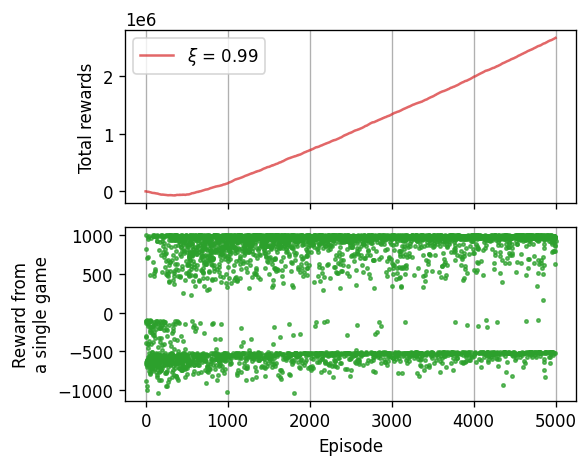

In [11]:
solver.plot_train_history(reward_history, total_reward_history)

In [12]:
# use a wrapper to create a human-renderable env from the original
human_env = HumanRendering(wrapped_env)

In [13]:
play_game(solver.agent, human_env, num_episodes=1)

--- Episode 1 Starting ---
Episode Finished. Num steps: 28; Total reward: 983.50


### Training Agent - DQN

In [ ]:
env_v2 = GridWorldEnv(grid=huge_grid, reward=huge_world_reward, wind_p=0.0, step_limit=5000, render_mode="rgb_array")

# Create a wrapper that maps gridworld position to state integer
wrapped_env_v2 = DiscreteGridWorldWrapper(env_v2)
# This automatically calculates episode returns and lengths and puts them in `info["episode"]`
wrapped_env_v2 = RecordEpisodeStatistics(wrapped_env_v2)
# This will save an mp4 file in the "videos" folder every 50 episodes
wrapped_env_v2 = RecordVideo(
    wrapped_env_v2,
    video_folder="../runtime/videos",
    episode_trigger=lambda episode_id: episode_id % 100 == 0,
    disable_logger=True # Keeps the console clean
)

d:\00_Dev\repos\rl-study\.venv\lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at d:\00_Dev\repos\rl-study\runtime\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [4]:
dqn_learner_kwargs = {
    "gamma": 0.95, # discount factor for Q' when computing delta ( delta = r + gamma * Q' - Q(s, a) )
    "alpha": 1e-3, # 'learning rate' - affects step size in direction of delta when updating Q
    "epsilon": 1.0, # exploration threshold
    "xi": 0.9999, # exploration threshold decay
    "r_scaling": 1.0 / env_v2.get_max_abs_reward(), # reward scaling - scale rewards based on the maximum abs reward in the env - so the max reward will be 1. This is done to prevent gradient explosion
    # QNetwork
    "hidden_dim": 64,
    "batch_size": 32,
    "target_update_freq": 1000,
    "train_every_n": 4,
}

In [5]:
dqn_solver = GridWorldSolver(wrapped_env_v2, DQNAgent, dqn_learner_kwargs, verbose=True)

In [ ]:
dqn_solver.train(n_epochs=2000)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: craiucalin (craiucalin-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch:  35%|███▍      | 691/2000 [03:35<05:51,  3.72it/s]

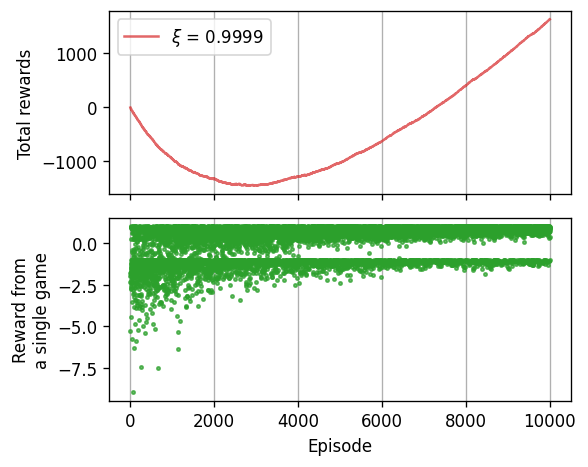

In [10]:
dqn_solver.plot_train_history(reward_history, total_reward_history)

In [11]:
human_env_v2 = HumanRendering(env_v2)

In [ ]:
play_game(dqn_solver.agent, human_env_v2, num_episodes=1)

--- Episode 1 Starting ---


TypeError: 'dict' object cannot be interpreted as an integer

: 